In [49]:
!pip install keras==2.15 tensorflow==2.15 tensorflow_addons

/usr/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [50]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint
import tensorflow_addons as tfa
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [51]:
tf.random.set_global_generator(tf.random.Generator.from_seed(seed=42))
tf.random.set_seed(42)
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

In [52]:
df = pd.read_excel('/kaggle/input/datasets/alialrekan/local-beauty/Dataset.xlsx')
df['image name'] = '/kaggle/input/datasets/alialrekan/local-beauty/all images/all images/'+df['image name']

df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['gender']) # 30% of data go to df_test
df_test, df_valid = train_test_split(df_test, test_size=0.5, random_state=42, stratify=df_test['gender']) # 15% valid and 15% testing

In [53]:
def load_data(im_path, label_score):
    image = tf.io.read_file(im_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [384, 384])
    return image, label_score


def create_dataset(df):
    im_paths = df['image name'].values.astype('str')
    labels_score = df['final rating'].values.astype('float32')
   
    dataset = tf.data.Dataset.from_tensor_slices((im_paths, labels_score))
    dataset = dataset.map(load_data, num_parallel_calls=tf.data.AUTOTUNE)
    return  dataset

train_dataset = create_dataset(df_train)
valid_dataset = create_dataset(df_valid)
test_dataset = create_dataset(df_test)

batch_size=32
train_dataset = train_dataset.shuffle(1024).batch(batch_size).prefetch(tf.data.AUTOTUNE)
valid_dataset = valid_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [54]:
input_layer = layers.Input((384,384,3))
x = layers.RandomFlip(mode="horizontal")(input_layer)
x= layers.Lambda(tf.keras.applications.mobilenet.preprocess_input)(x)
model = tf.keras.applications.MobileNet( 
    include_top=False,
    weights="imagenet",
    input_tensor = x, # x input_layer
    pooling='avg'
)

act='relu' # swish relu elu
x = layers.Dense(64, activation=act)(model.output)
x = layers.Dense(32, activation=act)(x)
x = layers.Dense(1, activation='sigmoid')(x)
output1 = layers.Lambda(lambda x: x*4+1, name='Score')(x)





model1 = Model(model.input, output1)

In [55]:
input_layer = layers.Input((384,384,3))
x = layers.RandomFlip(mode="horizontal")(input_layer)
model = tf.keras.applications.EfficientNetV2B0( 
    include_top=False,
    weights="imagenet",
    input_tensor = x, # x input_layer
    pooling='avg'
)

act='relu' # swish relu elu
x = layers.Dense(64, activation=act)(model.output)
x = layers.Dense(32, activation=act)(x)
x = layers.Dense(1, activation='sigmoid')(x)
output1 = layers.Lambda(lambda x: x*4+1, name='Score')(x)





model2 = Model(model.input, output1)

In [56]:
input_layer = layers.Input((384,384,3))
x = layers.RandomFlip(mode="horizontal")(input_layer)
model = tf.keras.applications.EfficientNetV2B1( 
    include_top=False,
    weights="imagenet",
    input_tensor = x, # x input_layer
    pooling='avg'
)

act='relu' # swish relu elu
x = layers.Dense(64, activation=act)(model.output)
x = layers.Dense(32, activation=act)(x)
x = layers.Dense(1, activation='sigmoid')(x)
output1 = layers.Lambda(lambda x: x*4+1, name='Score')(x)




model3 = Model(model.input, output1)

In [57]:
#model.summary()

In [58]:
tlr = tfa.optimizers.TriangularCyclicalLearningRate(
        initial_learning_rate = 1e-5,
        maximal_learning_rate = 1e-3,
        step_size = len(train_dataset),
        scale_mode = "cycle")

optimizer = tf.keras.optimizers.AdamW(learning_rate=tlr)
loss = tf.keras.losses.Huber(delta=0.5)
metrics = tf.keras.metrics.RootMeanSquaredError()

model1.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=metrics
)

model2.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=metrics
)

model3.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=metrics
)

In [59]:
# Define the checkpoint callback كيش ايبوخ جيتره 
checkpoint = ModelCheckpoint(
    filepath="model_checkpoint.h5",
    monitor="val_Score_root_mean_squared_error", # val_loss
    save_best_only=True,
    verbose=1
)

In [60]:
#history = model.fit(train_dataset,validation_data=valid_dataset,epochs=100, callbacks=[checkpoint])

In [61]:
model1.load_weights('/kaggle/input/datasets/alialrekan/bb-ssss/mobile.h5')
model2.load_weights('/kaggle/input/datasets/alialrekan/bb-ssss/eff_b0.h5')
model3.load_weights('/kaggle/input/datasets/alialrekan/bb-ssss/eff_b1.h5')

In [66]:
y_pred1 = model1.predict(test_dataset).flatten()
y_pred2 = model2.predict(test_dataset).flatten()
y_pred3 = model3.predict(test_dataset).flatten()

4/4 [==============================] - 0s 77ms/step


In [95]:
y_pred = (y_pred2+y_pred1+y_pred3)/3.0
y_true = df_test['final rating'].values

In [96]:
rmse=tf.keras.metrics.RootMeanSquaredError()(y_true,y_pred)
mae=tf.keras.metrics.MeanAbsoluteError()(y_true,y_pred)

In [97]:
# Calculate the Pearson correlation coefficient matrix
correlation_matrix = np.corrcoef(y_true, y_pred)

# Extract the Pearson correlation coefficient
pearson_corr = correlation_matrix[0, 1]

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"PC: {pearson_corr:.4f}")

RMSE: 0.5095
MAE: 0.4091
PC: 0.5847


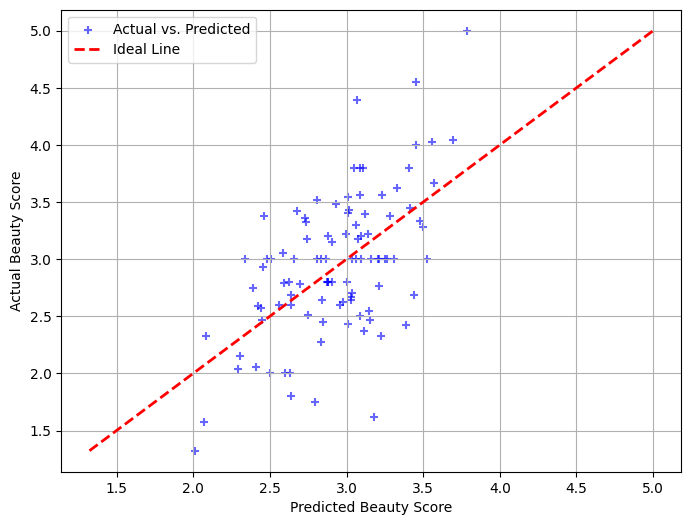

In [98]:
# Plotting y_true vs y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred,y_true, marker='+', color='blue', alpha=0.6, label='Actual vs. Predicted')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], color='red', linestyle='--', linewidth=2, label='Ideal Line')

# Add labels and title
plt.xlabel('Predicted Beauty Score')
plt.ylabel('Actual Beauty Score')
plt.legend()
plt.grid(True)
plt.savefig('effenenet.svg', dpi=600,bbox_inches='tight', pad_inches=0)